In [1]:
#import reqiured libraries
import pandas as pd
import numpy as np

In [2]:
# Load the dataset
data = pd.read_csv('Loan Prediction Train.csv')
print(data.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [3]:
# Data Preprocessing
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
# Check for missing values
print(data.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [6]:
# handle missing values
data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
data['Dependents'].fillna(data['Dependents'].mode()[0], inplace=True)
data['Self_Employed'].fillna(data['Self_Employed'].mode()[0], inplace=True)
data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace=True)
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0], inplace=True)
data['Credit_History'].fillna(data['Credit_History'].median(), inplace=True)

C:\Users\HOME\AppData\Local\Temp\ipykernel_42632\1821312200.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
C:\Users\HOME\AppData\Local\Temp\ipykernel_42632\1821312200.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [7]:
data['Married'].fillna(data['Married'].mode()[0], inplace=True)

C:\Users\HOME\AppData\Local\Temp\ipykernel_42632\177296164.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Married'].fillna(data['Married'].mode()[0], inplace=True)


In [8]:
# check for missing values again
print(data.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


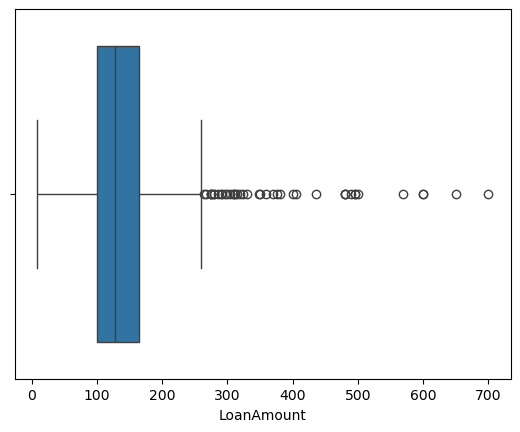

In [9]:
# check for outliers
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x=data['LoanAmount'])
plt.show()

In [10]:
data['Credit_History'].value_counts()

Credit_History
1.0    525
0.0     89
Name: count, dtype: int64

In [11]:
data['Dependents'] = data['Dependents'].replace('3+', '3').astype(int)

In [12]:
data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})

In [13]:
print(data['Loan_Status'].value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64


<Axes: xlabel='CoapplicantIncome', ylabel='count'>

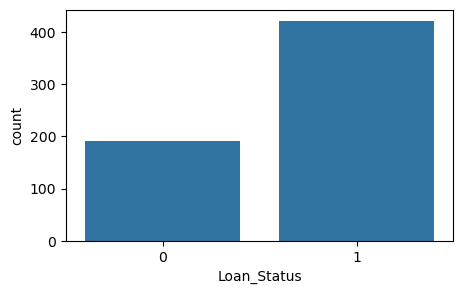

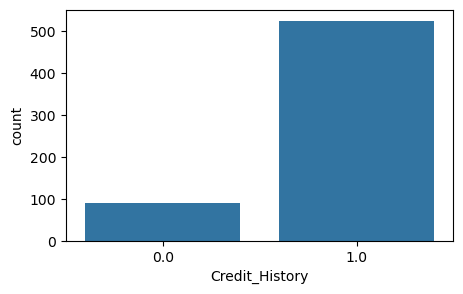

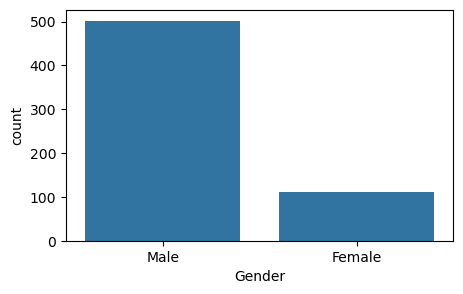

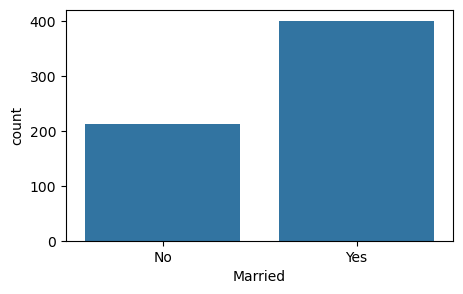

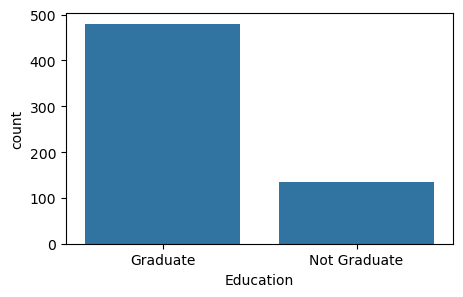

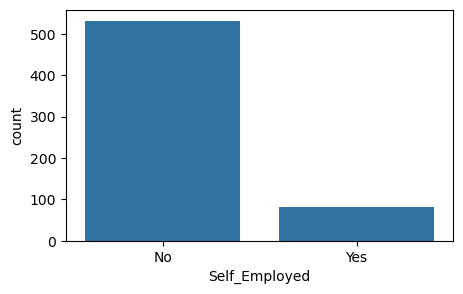

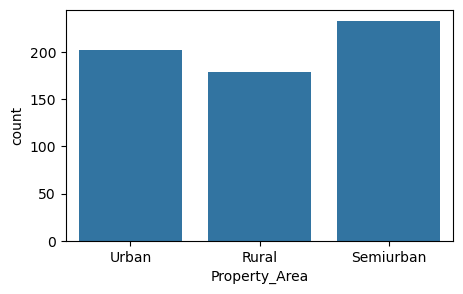

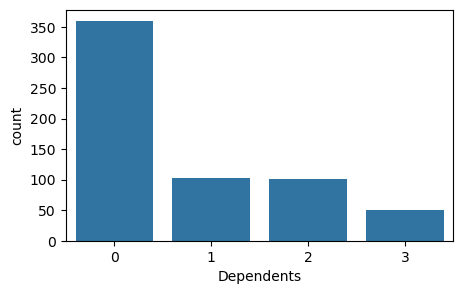

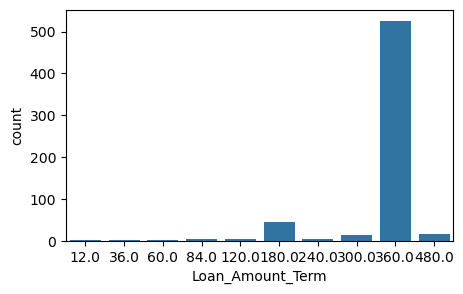

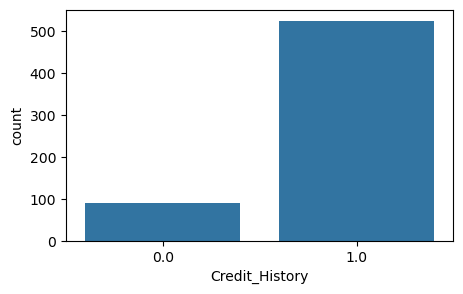

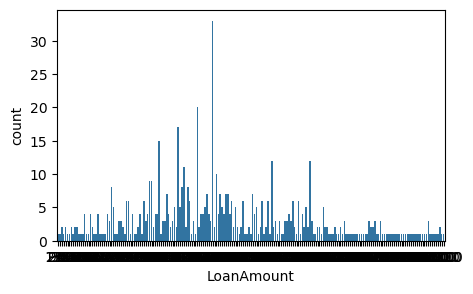

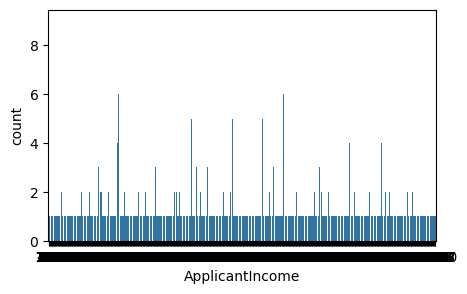

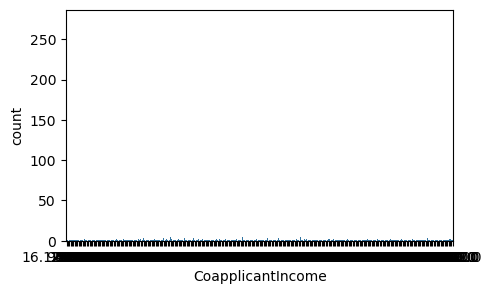

In [14]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(5, 3))
sns.countplot(x= 'Loan_Status', data=data)
plt.figure(figsize=(5,3))
sns.countplot(x='Credit_History', data=data)
plt.figure(figsize=(5, 3))
sns.countplot(x='Gender', data=data)
plt.figure(figsize=(5, 3))
sns.countplot(x='Married', data=data)
plt.figure(figsize=(5, 3))
sns.countplot(x='Education', data=data)
plt.figure(figsize=(5, 3))
sns.countplot(x='Self_Employed', data=data)
plt.figure(figsize=(5, 3))
sns.countplot(x='Property_Area', data=data)
plt.figure(figsize=(5, 3))
sns.countplot(x='Dependents', data=data)
plt.figure(figsize=(5, 3))
sns.countplot(x='Loan_Amount_Term', data=data)
plt.figure(figsize=(5, 3))
sns.countplot(x='Credit_History', data=data)
plt.figure(figsize=(5, 3))
sns.countplot(x='LoanAmount', data=data)
plt.figure(figsize=(5, 3))
sns.countplot(x='ApplicantIncome', data=data)
plt.figure(figsize=(5, 3))
sns.countplot(x='CoapplicantIncome', data=data)


In [15]:
# Encode only if datatype is object

if data['Gender'].dtype == 'object':
    data['Gender'] = data['Gender'].map({
        'Male':1,
        'Female':0
    })

if data['Married'].dtype == 'object':
    data['Married'] = data['Married'].map({
        'Yes':1,
        'No':0
    })

if data['Education'].dtype == 'object':
    data['Education'] = data['Education'].map({
        'Graduate':1,
        'Not Graduate':0
    })

if data['Self_Employed'].dtype == 'object':
    data['Self_Employed'] = data['Self_Employed'].map({
        'Yes':1,
        'No':0
    })

if data['Property_Area'].dtype == 'object':
    data['Property_Area'] = data['Property_Area'].map({
        'Rural':0,
        'Semiurban':1,
        'Urban':2
    })

In [16]:
# Drop Loan_ID
data.drop("Loan_ID", axis=1, inplace=True)

# Selecting features and target variable AFTER encoding

X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

print(X.head())
print(y.head())

print(X.shape)

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          1              0             5849   
1       1        1           1          1              0             4583   
2       1        1           0          1              1             3000   
3       1        1           0          0              0             2583   
4       1        0           0          1              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Property_Area  
0              2  
1              0  
2              2  
3              2  
4              2  
0 

In [17]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(491, 11) (123, 11) (491,) (123,)


In [18]:
# Train a Logistic Regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
# Calculate m and c for the logistic regression model
m = model.coef_[0][0]
c = model.intercept_[0]
print("Coefficients (m):", m)
print("Intercept (c):", c)

Coefficients (m): 0.013567223527782921
Intercept (c): 0.09386284929221546


In [20]:
# make predictions
y_pred = model.predict(X_test)
print("Predictions:", y_pred)

Predictions: [1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1
 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 1]


In [21]:
# Actual vs Predicted
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head())

     Actual  Predicted
350       1          1
377       1          1
163       1          1
609       1          1
132       1          1


In [22]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[18 25]
 [ 1 79]]


In [23]:
# Calculate accuracy of the model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Calculate precision, recall, and F1-score
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7886178861788617
Precision: 0.7596153846153846
Recall: 0.9875
F1 Score: 0.8586956521739131


In [24]:
# Calculate classification report
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [25]:
# use Loan Prediction Test.csv to test
test_data = pd.read_csv("Loan Prediction Test.csv")
print(test_data.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4             3276                  0        78.0             360.0   

   Credit_History Property_Area  
0             1.0         Urban  
1             1.0         Urban  
2             1.0         Urban  
3             NaN     

In [50]:
# make predictions on test data
test_data['Dependents'] = test_data['Dependents'].replace('3+', '3').astype(int)
test_data = pd.get_dummies(test_data, drop_first=True)
test_data = test_data.reindex(columns=X.columns, fill_value=0)
test_predictions = model.predict(test_data)
print("Test Predictions:", test_predictions)

ValueError: cannot convert float NaN to integer

In [26]:
import pickle

pickle.dump(model, open('loan_model.pkl', 'wb'))

print("Model saved successfully!")

Model saved successfully!
